EX : 4

Probabilistic Classification using Naïve Bayes
(Gaussian & Multinomial Naïve Bayes)


Scenario 1 : To Built a probabilistic classification model to detect whether a message is Spam or Ham based on its textual content

NEHA.N.K | 24BAD078

Model Performance
Accuracy : 0.97847533632287
Precision: 0.9256756756756757
Recall   : 0.9133333333333333
F1 Score : 0.9194630872483222

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.91      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



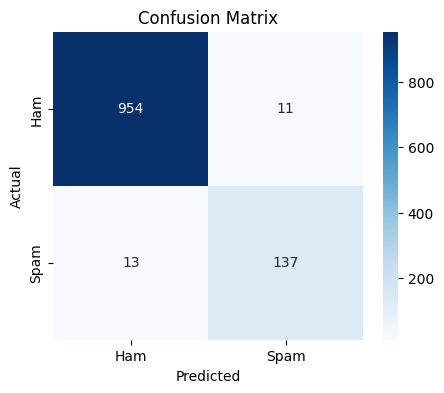

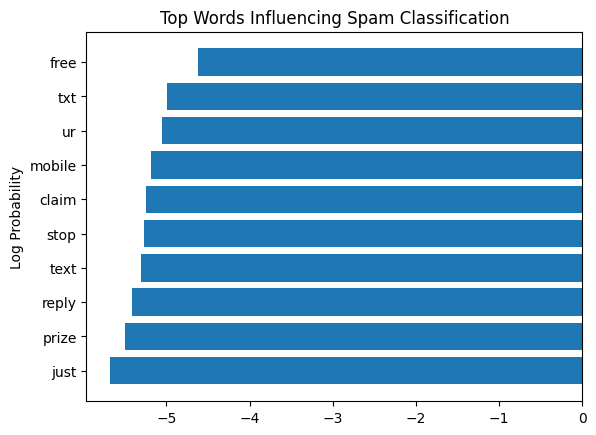

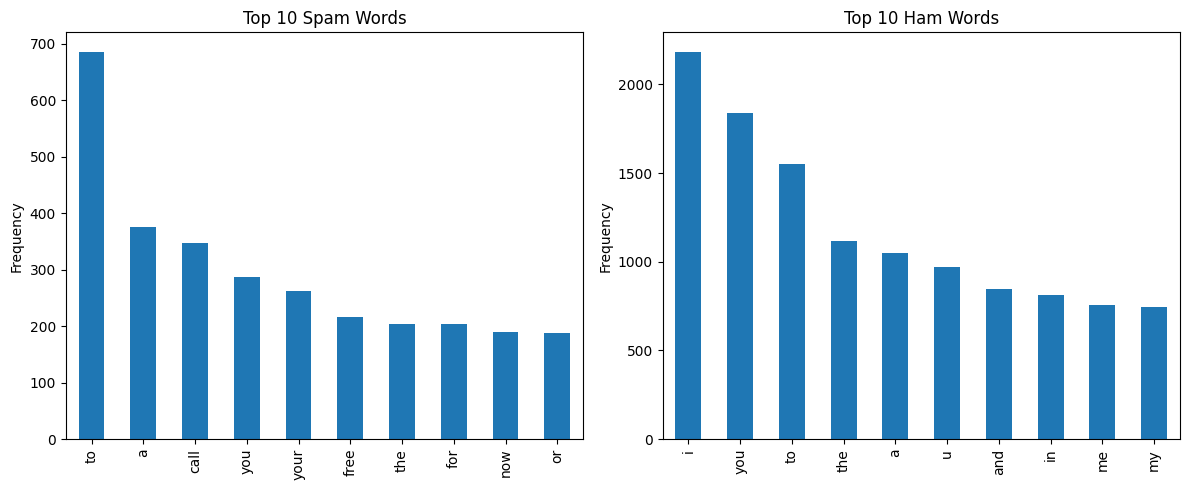

In [ ]:
# EXPT NO: 4 – Multinomial Naive Bayes
# Name: NEHA.N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

# Loading Dataset
data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

# Text Cleaning
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

data['clean_message'] = data['message'].apply(clean_text)

# Converting Text to Numerical Features (Count Vectorizer)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_message'])

# Encoding Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['label'])  # spam=1, ham=0

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training Model (Laplace Smoothing alpha=1)
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print("\nModel Performance")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# VISUALIZATION 1 – CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# VISUALIZATION 2 – TOP WORDS INFLUENCING SPAM
feature_names = np.array(vectorizer.get_feature_names_out())
spam_log_probs = model.feature_log_prob_[1]

top_indices = np.argsort(spam_log_probs)[-10:]
top_words = feature_names[top_indices]
top_values = spam_log_probs[top_indices]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top Words Influencing Spam Classification")
plt.ylabel("Log Probability")
plt.show()


# VISUALIZATION 3 – WORD FREQUENCY (Spam vs Ham)
spam_messages = data[data['label']=='spam']['clean_message']
ham_messages = data[data['label']=='ham']['clean_message']

spam_words = ' '.join(spam_messages).split()
ham_words = ' '.join(ham_messages).split()

spam_freq = pd.Series(spam_words).value_counts().head(10)
ham_freq = pd.Series(ham_words).value_counts().head(10)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
spam_freq.plot(kind='bar')
plt.title("Top 10 Spam Words")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
ham_freq.plot(kind='bar')
plt.title("Top 10 Ham Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



**Model Performance Metrics**

Accuracy: Shows the overall percentage of correctly classified messages (spam and ham).
High accuracy indicates the model performs well on the dataset.

Precision (Spam class): Out of all messages predicted as spam, how many were actually spam.
High precision means fewer false positives (ham incorrectly classified as spam).

Recall (Spam class): Out of all actual spam messages, how many were correctly detected.
High recall means fewer false negatives (spam missed as ham).

F1-Score: Harmonic mean of precision and recall.
A high F1-score indicates a good balance between detecting spam and avoiding misclassification.

2.**Confusion Matrix Interpretation**

The confusion matrix shows:

True Positives (TP) → Spam correctly identified

True Negatives (TN) → Ham correctly identified

False Positives (FP) → Ham wrongly predicted as spam

False Negatives (FN) → Spam wrongly predicted as ham

If diagonal values (TP & TN) are high and off-diagonal values (FP & FN) are low, the model is performing well.

3.**Top Words Influencing Spam Classification**

The bar graph shows the top 10 words with highest log probability for spam class.

These words strongly indicate spam messages.

Multinomial Naive Bayes uses word frequency probabilities to classify text.

This confirms that the model is learning meaningful spam-related words.


4️. **Word Frequency Visualization (Spam vs Ham)**

Spam messages contain promotional or urgent words more frequently.

Ham messages contain common conversational words.

The difference in word frequency helps the model distinguish between spam and ham effectively.

Scenario 2 : TO Predict the species of Iris flower using:
Sepal Length,
Sepal Width,
Petal Length,
Petal Width

NEHA.N.K | 24BAD078
First 5 Rows:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Gaussian Naïve Bayes Performance
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg 

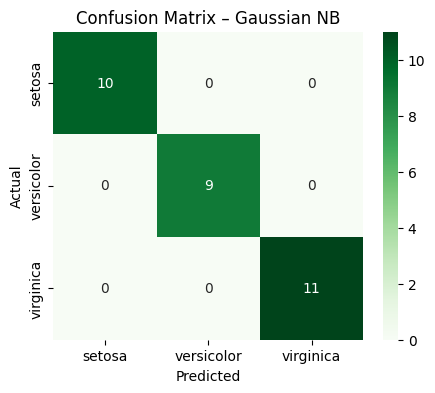

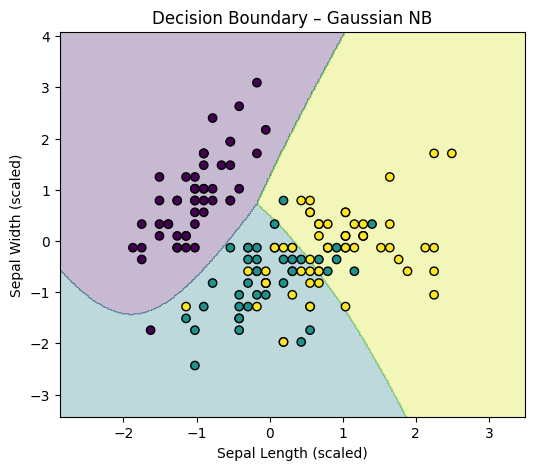

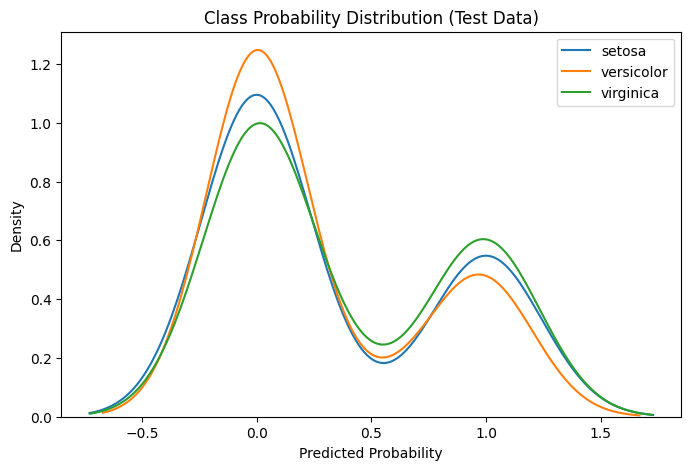

In [ ]:
# EXPT NO: 4 – Gaussian Naive Bayes
# Name: NEHA .N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Converting  to DataFrame for inspection
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

print("First 5 Rows:\n")
print(df.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Gaussian Naïve Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Evaluation Metrics
print("\nGaussian Naïve Bayes Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Comparing with Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

# VISUALIZATION 1 – CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Gaussian NB")
plt.show()

# VISUALIZATION 2 – DECISION BOUNDARY
# (Using first two features: Sepal Length & Width)
X_db = X_scaled[:, :2]  # first two features

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db, y, test_size=0.2, random_state=42
)

model_db = GaussianNB()
model_db.fit(X_train_db, y_train_db)

# Creating mesh grid
x_min, x_max = X_db[:,0].min() - 1, X_db[:,0].max() + 1
y_min, y_max = X_db[:,1].min() - 1, X_db[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_db.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_db[:,0], X_db[:,1], c=y, edgecolor='k')
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("Decision Boundary – Gaussian NB")
plt.show()

# VISUALIZATION 3 – PROBABILITY DISTRIBUTION PLOT
probs = gnb.predict_proba(X_test)

plt.figure(figsize=(8,5))
for i in range(3):
    sns.kdeplot(probs[:, i], label=class_names[i])

plt.title("Class Probability Distribution (Test Data)")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()



### 1️. Dataset Overview

* The **Iris Dataset** contains 3 classes:

  * Setosa
  * Versicolor
  * Virginica
* Each sample has 4 numerical features:

  * Sepal Length
  * Sepal Width
  * Petal Length
  * Petal Width

The first 5 rows confirm that the dataset is clean and properly structured.
## Model Performance – Gaussian Naïve Bayes

### Accuracy

* Accuracy shows the percentage of correctly classified flower species.
* A high accuracy (usually above 90% for Iris) indicates that Gaussian NB performs well.

###  Classification Report

* **Precision** → Correct predictions out of total predicted for each class.
* **Recall** → Correct predictions out of actual instances for each class.
* **F1-score** → Balance between precision and recall.

If all values are high and balanced, the model classifies all three species effectively.


##  Comparison with Logistic Regression

* **Logistic Regression** accuracy is printed for comparison.
* If Logistic Regression accuracy is slightly higher, it means:

  * Logistic Regression handles feature relationships better.
* If Gaussian NB accuracy is similar:

  * It shows that the Gaussian distribution assumption works well for this dataset.

## Confusion Matrix Interpretation

* Diagonal values → Correct classifications
* Off-diagonal values → Misclassifications

If most values are on the diagonal:

* The model correctly distinguishes between Setosa, Versicolor, and Virginica.
* Usually, Setosa is perfectly classified because it is linearly separable.

## Decision Boundary Plot

* The decision boundary is plotted using only:

  * Sepal Length
  * Sepal Width

Interpretation:

* Different colored regions show predicted classes.
* Clear separation indicates good classification.
* Some overlap between Versicolor and Virginica is normal because they have similar features.


## Probability Distribution Plot

* The KDE plot shows predicted probabilities for each class.
* If curves are well separated:

  * The model is confident in its predictions.
* If curves overlap:

  * Some samples are uncertain between classes.

